In [1]:
# =========================
# STEP 1: CHECK TEMPORAL GROUPING
# =========================

import pystac
from collections import defaultdict
import os

os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

collection = pystac.Collection.from_file(url)
items = list(collection.get_items())

# Filter GEO + HH
geo_items = [item for item in items if "GEO" in item.id]
clean_items = [item for item in geo_items if "HH" in item.assets]

print("Total usable items:", len(clean_items))

# Group by location (approx using bbox center)
location_groups = defaultdict(list)

for item in clean_items:
    bbox = item.bbox  # [minx, miny, maxx, maxy]
    
    center_lat = (bbox[1] + bbox[3]) / 2
    center_lon = (bbox[0] + bbox[2]) / 2
    
    # round to cluster nearby locations
    key = (round(center_lat, 2), round(center_lon, 2))
    
    location_groups[key].append(item)

# Find locations with multiple timestamps
multi_time_locations = {
    k: v for k, v in location_groups.items() if len(v) > 1
}

print("\nLocations with multiple timestamps:", len(multi_time_locations))

# Show one example
for k, v in list(multi_time_locations.items())[:1]:
    print("\nSample location:", k)
    print("Number of images:", len(v))
    
    for item in v[:5]:
        print(" -", item.datetime)

print("\nDone ✅")

Total usable items: 760

Locations with multiple timestamps: 47

Sample location: (19.42, -155.29)
Number of images: 188
 - 2025-11-12 02:24:47.676937+00:00
 - 2025-11-11 12:28:56.582521+00:00
 - 2025-11-09 03:28:02.304377+00:00
 - 2025-11-08 13:32:12.226841+00:00
 - 2025-11-06 04:31:19.292211+00:00

Done ✅


In [2]:
# =========================
# STEP 2: SELECT RICHEST LOCATION
# =========================

# assuming multi_time_locations exists from previous run

# find location with maximum images
best_location = max(multi_time_locations.items(), key=lambda x: len(x[1]))

location_key = best_location[0]
location_items = best_location[1]

print("Selected location:", location_key)
print("Total timestamps:", len(location_items))

# sort by time (important)
location_items = sorted(location_items, key=lambda x: x.datetime)

# show first few timestamps
print("\nFirst 5 timestamps:")
for item in location_items[:5]:
    print(item.datetime)

print("\nLast 5 timestamps:")
for item in location_items[-5:]:
    print(item.datetime)

print("\nDone ✅")

Selected location: (19.42, -155.29)
Total timestamps: 188

First 5 timestamps:
2025-01-08 02:08:34.973917+00:00
2025-01-08 16:04:25.047451+00:00
2025-01-11 01:05:17.988782+00:00
2025-01-11 15:01:08.487680+00:00
2025-01-14 00:02:04.224887+00:00

Last 5 timestamps:
2025-11-06 04:31:19.292211+00:00
2025-11-08 13:32:12.226841+00:00
2025-11-09 03:28:02.304377+00:00
2025-11-11 12:28:56.582521+00:00
2025-11-12 02:24:47.676937+00:00

Done ✅


In [3]:
# =========================
# STEP 3: SELECT TEMPORAL SUBSET
# =========================

import numpy as np

# location_items already sorted

NUM_SELECT = 20

indices = np.linspace(0, len(location_items) - 1, NUM_SELECT, dtype=int)

selected_items = [location_items[i] for i in indices]

print("Selected timestamps:\n")

for item in selected_items:
    print(item.datetime)

print("\nTotal selected:", len(selected_items))

Selected timestamps:

2025-01-08 02:08:34.973917+00:00
2025-01-20 11:51:20.843921+00:00
2025-02-06 15:35:55.004556+00:00
2025-02-21 10:19:34.748849+00:00
2025-03-11 17:55:49.881349+00:00
2025-03-31 20:37:09.850050+00:00
2025-04-15 15:20:49.736303+00:00
2025-04-28 01:03:36.362353+00:00
2025-05-12 19:47:17.804074+00:00
2025-05-27 14:30:57.049743+00:00
2025-06-11 09:14:37.324586+00:00
2025-06-26 03:58:02.373135+00:00
2025-07-13 07:42:33.799728+00:00
2025-08-12 11:06:01.777273+00:00
2025-08-27 05:49:43.572820+00:00
2025-09-11 00:33:23.955348+00:00
2025-09-28 18:13:47.605659+00:00
2025-10-13 12:57:27.001281+00:00
2025-10-28 07:41:08.051239+00:00
2025-11-12 02:24:47.676937+00:00

Total selected: 20


In [4]:
# =========================
# STEP 4 (FIXED): FAST DOWNLOAD
# =========================

import os
import requests
from tqdm import tqdm

SAVE_DIR = "sar_data"
os.makedirs(SAVE_DIR, exist_ok=True)

local_paths = []

print("Downloading images (fast mode)...\n")

for idx, item in enumerate(selected_items):
    url = item.assets["HH"].href
    
    filename = f"image_{idx:02d}.tif"
    save_path = os.path.join(SAVE_DIR, filename)
    
    # skip if already exists
    if os.path.exists(save_path):
        print(f"[{idx}] Already exists, skipping")
        local_paths.append(save_path)
        continue
    
    try:
        response = requests.get(url, stream=True, timeout=60)
        total_size = int(response.headers.get('content-length', 0))
        
        with open(save_path, 'wb') as f, tqdm(
            total=total_size,
            unit='B',
            unit_scale=True,
            desc=f"Image {idx}"
        ) as bar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))
        
        local_paths.append(save_path)

    except Exception as e:
        print(f"[{idx}] Error:", e)

print("\nDownload complete ✅")
print("Total images saved:", len(local_paths))


[0] Already exists, skipping
[1] Already exists, skipping
[2] Already exists, skipping
[3] Already exists, skipping
[4] Already exists, skipping
[5] Already exists, skipping
[6] Already exists, skipping
[7] Already exists, skipping
[8] Already exists, skipping
[9] Already exists, skipping
[10] Already exists, skipping
[11] Already exists, skipping
[12] Already exists, skipping
[13] Already exists, skipping
[14] Already exists, skipping


Image 15: 100%|███████████████████████████████████████████████████████████████████| 1.69G/1.69G [05:42<00:00, 4.94MB/s]
Image 16: 100%|███████████████████████████████████████████████████████████████████| 1.70G/1.70G [06:35<00:00, 4.29MB/s]
Image 17: 100%|███████████████████████████████████████████████████████████████████| 1.69G/1.69G [04:42<00:00, 5.97MB/s]
Image 18: 100%|███████████████████████████████████████████████████████████████████| 1.67G/1.67G [05:24<00:00, 5.16MB/s]
Image 19: 100%|███████████████████████████████████████████████████████████████████| 1.67G/1.67G [05:05<00:00, 5.46MB/s]


Download complete ✅
Total images saved: 20


In [5]:
# =========================
# STEP 5: LOAD LOCAL IMAGES (FAST)
# =========================

import os
import rasterio
import numpy as np

DATA_DIR = "sar_data"
TARGET_SIZE = 2048  # keep consistent

image_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".tif")])

images = []

print("Loading local images...\n")

for idx, file in enumerate(image_files):
    path = os.path.join(DATA_DIR, file)
    
    try:
        with rasterio.open(path) as src:
            img = src.read(
                1,
                out_shape=(1, TARGET_SIZE, TARGET_SIZE)
            )
        
        images.append(img)
        print(f"[{idx+1}/{len(image_files)}] Loaded")

    except Exception as e:
        print(f"[{idx}] Error:", e)

print("\nAll images loaded ✅")
print("Total images:", len(images))
print("Image shape:", images[0].shape)

Loading local images...

[1/20] Loaded
[2/20] Loaded
[2] Error: Read failed. See previous exception for details.
[4/20] Loaded
[4] Error: Read failed. See previous exception for details.
[6/20] Loaded
[7/20] Loaded
[8/20] Loaded
[9/20] Loaded
[10/20] Loaded
[11/20] Loaded
[12/20] Loaded
[13/20] Loaded
[14/20] Loaded
[14] Error: Read failed. See previous exception for details.
[16/20] Loaded
[17/20] Loaded
[18/20] Loaded
[19/20] Loaded
[20/20] Loaded

All images loaded ✅
Total images: 17
Image shape: (2048, 2048)


In [6]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   --- ------------------------------------ 3.9/40.2 MB 45.8 MB/s eta 0:00:01
   -------------- ------------------------- 14.9/40.2 MB 50.7 MB/s eta 0:00:01
   ----------------------------- ---------- 29.4/40.2 MB 57.7 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 56.9 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 50.9 MB/s  0:00:00


In [7]:
# =========================
# STEP 5 (FIXED): LOAD + RESIZE SAFELY
# =========================

import os
import rasterio
import numpy as np
import cv2  # IMPORTANT

DATA_DIR = "sar_data"
TARGET_SIZE = 2048

image_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".tif")])

images = []
valid_files = []

print("Loading and resizing images...\n")

for idx, file in enumerate(image_files):
    path = os.path.join(DATA_DIR, file)
    
    try:
        with rasterio.open(path) as src:
            img = src.read(1)  # read original size
        
        # resize safely
        img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
        
        images.append(img_resized)
        valid_files.append(file)

        print(f"[{idx+1}] Loaded + resized")

    except Exception as e:
        print(f"[{idx+1}] Skipped ❌:", e)

print("\nDone ✅")
print("Total valid images:", len(images))
print("Final shape:", images[0].shape)

Loading and resizing images...

[1] Loaded + resized
[2] Loaded + resized
[3] Skipped ❌: Read failed. See previous exception for details.
[4] Loaded + resized
[5] Skipped ❌: Read failed. See previous exception for details.
[6] Loaded + resized
[7] Loaded + resized
[8] Loaded + resized
[9] Loaded + resized
[10] Loaded + resized
[11] Loaded + resized
[12] Loaded + resized
[13] Loaded + resized
[14] Loaded + resized
[15] Skipped ❌: Read failed. See previous exception for details.
[16] Loaded + resized
[17] Loaded + resized
[18] Loaded + resized
[19] Loaded + resized
[20] Loaded + resized

Done ✅
Total valid images: 17
Final shape: (2048, 2048)


In [8]:
# =========================
# STEP 6: TEMPORAL PATCH EXTRACTION
# =========================

PATCH_SIZE = 256
STRIDE = 256

patches = []
time_ids = []   # 🔥 IMPORTANT (tracks timestamp index)
positions = []  # 🔥 IMPORTANT (tracks spatial location)

print("Extracting patches with temporal info...\n")

for t, img in enumerate(images):  # t = time index
    
    h, w = img.shape
    count = 0

    for i in range(0, h - PATCH_SIZE, STRIDE):
        for j in range(0, w - PATCH_SIZE, STRIDE):
            
            patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            
            patches.append(patch)
            time_ids.append(t)
            positions.append((i, j))
            
            count += 1

    print(f"[Time {t}] patches:", count)

print("\nDone ✅")
print("Total patches:", len(patches))

Extracting patches with temporal info...

[Time 0] patches: 49
[Time 1] patches: 49
[Time 2] patches: 49
[Time 3] patches: 49
[Time 4] patches: 49
[Time 5] patches: 49
[Time 6] patches: 49
[Time 7] patches: 49
[Time 8] patches: 49
[Time 9] patches: 49
[Time 10] patches: 49
[Time 11] patches: 49
[Time 12] patches: 49
[Time 13] patches: 49
[Time 14] patches: 49
[Time 15] patches: 49
[Time 16] patches: 49

Done ✅
Total patches: 833


In [9]:
# =========================
# STEP 7: PREPROCESS + TENSOR
# =========================

import numpy as np
import torch

processed = []

print("Preprocessing patches...\n")

for idx, patch in enumerate(patches):
    
    patch = patch.astype(np.float32)
    
    # dB conversion (SAR specific)
    patch = 10 * np.log10(patch + 1e-10)
    
    # normalize
    mean = patch.mean()
    std = patch.std() + 1e-6
    patch = (patch - mean) / std
    
    processed.append(patch)

    if (idx + 1) % 100 == 0:
        print(f"Processed {idx+1}/{len(patches)}")

processed = np.array(processed)

# convert to tensor
tensor_data = torch.tensor(processed).unsqueeze(1)

print("\nDone ✅")
print("Tensor shape:", tensor_data.shape)

Preprocessing patches...

Processed 100/833
Processed 200/833
Processed 300/833
Processed 400/833
Processed 500/833
Processed 600/833
Processed 700/833
Processed 800/833

Done ✅
Tensor shape: torch.Size([833, 1, 256, 256])


In [10]:
# =========================
# STEP 8: MODEL + TRAINING
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# dataset
dataset = TensorDataset(tensor_data)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 3, 2, 1, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 3, 2, 1, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder().to(device)

# loss + optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15

print("\nStarting training...\n")

for epoch in range(EPOCHS):
    total_loss = 0

    for (data,) in dataloader:
        data = data.to(device)

        output = model(data)
        loss = criterion(output, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss:.4f}")

# save model
torch.save(model.state_dict(), "autoencoder_final.pth")

print("\nTraining complete ✅")
print("Model saved as autoencoder_final.pth")

Using device: cuda

Starting training...

Epoch 1/15 Loss: 0.3750
Epoch 2/15 Loss: 0.2228
Epoch 3/15 Loss: 0.2084
Epoch 4/15 Loss: 0.1982
Epoch 5/15 Loss: 0.1855
Epoch 6/15 Loss: 0.1938
Epoch 7/15 Loss: 0.1729
Epoch 8/15 Loss: 0.1684
Epoch 9/15 Loss: 0.1603
Epoch 10/15 Loss: 0.1547
Epoch 11/15 Loss: 0.1559
Epoch 12/15 Loss: 0.1502
Epoch 13/15 Loss: 0.1489
Epoch 14/15 Loss: 0.1535
Epoch 15/15 Loss: 0.1353

Training complete ✅
Model saved as autoencoder_final.pth


In [11]:
# =========================
# STEP 9: FEATURE EXTRACTION (TEMPORAL)
# =========================

import torch

# load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
model.load_state_dict(torch.load("autoencoder_final.pth"))
model.eval()

features = []

print("Extracting features...\n")

with torch.no_grad():
    for (data,) in DataLoader(TensorDataset(tensor_data), batch_size=16):
        data = data.to(device)

        z = model.encoder(data)
        z = z.view(z.size(0), -1)

        features.append(z.cpu())

features = torch.cat(features)

print("Done ✅")
print("Feature shape:", features.shape)

C:\Users\Bramha\AppData\Local\Temp\ipykernel_22376\3925519916.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("autoencoder_final.pth"))

Extracting features...

Done ✅
Feature shape: torch.Size([833, 65536])


In [12]:
# =========================
# STEP 10: TEMPORAL CHANGE DETECTION
# =========================

import torch
import numpy as np

# convert to numpy
features_np = features.numpy()
time_ids_np = np.array(time_ids)
positions_np = np.array(positions)

print("Computing temporal changes...\n")

# group patches by spatial position
from collections import defaultdict

position_dict = defaultdict(list)

for idx, pos in enumerate(positions_np):
    position_dict[tuple(pos)].append(idx)

change_scores = []

# compute change over time for each position
for pos, indices in position_dict.items():
    
    # sort by time
    indices = sorted(indices, key=lambda x: time_ids_np[x])
    
    # get feature sequence
    seq = features_np[indices]
    
    # compute differences between consecutive timestamps
    diffs = np.linalg.norm(seq[1:] - seq[:-1], axis=1)
    
    # average change
    score = diffs.mean()
    
    change_scores.append((pos, score))

print("Done ✅")
print("Total spatial positions:", len(change_scores))

Computing temporal changes...

Done ✅
Total spatial positions: 49


Change map shape: (7, 7)


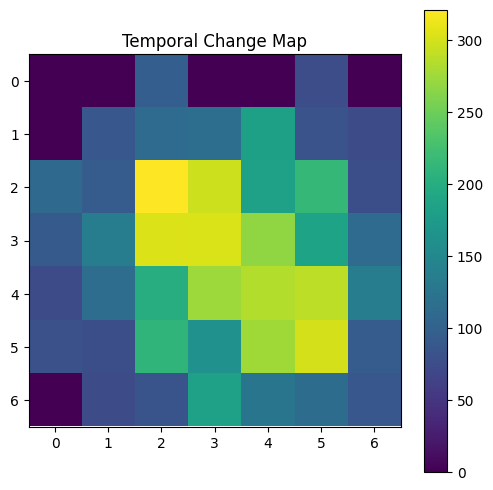

In [13]:
# =========================
# STEP 11: BUILD CHANGE MAP
# =========================

import numpy as np
import matplotlib.pyplot as plt

# initialize grid
grid_size = int(np.sqrt(len(change_scores)))  # should be 7

change_map = np.zeros((grid_size, grid_size))

# fill map
for (i, j), score in change_scores:
    x = i // 256
    y = j // 256
    change_map[x, y] = score

print("Change map shape:", change_map.shape)

# visualize
plt.figure(figsize=(6,6))
plt.imshow(change_map)
plt.colorbar()
plt.title("Temporal Change Map")
plt.show()

In [14]:
# =========================
# STEP 12: TOP CHANGING REGIONS
# =========================

# sort by highest change
sorted_changes = sorted(change_scores, key=lambda x: x[1], reverse=True)

TOP_K = 5

print("Top changing regions:\n")

for i in range(TOP_K):
    (pos, score) = sorted_changes[i]
    
    x = pos[0] // 256
    y = pos[1] // 256
    
    print(f"Rank {i+1}: Grid ({x}, {y}) | Score: {score:.2f}")

Top changing regions:

Rank 1: Grid (2, 2) | Score: 321.48
Rank 2: Grid (3, 2) | Score: 305.08
Rank 3: Grid (3, 3) | Score: 303.53
Rank 4: Grid (5, 5) | Score: 300.76
Rank 5: Grid (2, 3) | Score: 297.11
